In [ ]:
!pip install tensorflow

In [ ]:
#for downloading and accessing dataset
import os
from google.colab import drive
import shutil
import glob
from PIL import Image
import sys
from pycocotools.coco import COCO
import urllib
import zipfile

#for tensorflow classification and image printing
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential


In [ ]:
#get dataset from google drive folder

# Mount Google Drive
drive.mount('/content/drive')

# Path to the zip file in your Google Drive
google_drive_path = '/content/drive/My Drive/Spring2024/CS365/brain_tumor_images.zip'

# Destination path where you want to save the zip file
destination_path = '/content/brain_tumor_images.zip'

# Copy the file from Google Drive to Colab's local filesystem
shutil.copy(google_drive_path, destination_path)

print("File downloaded successfully!")


Mounted at /content/drive
File downloaded successfully!


In [ ]:
#extract folders from zip file

# Directory where you want to extract the images
extracted_images_dir = '/content/brain_tumor_set'

# Create the directory if it doesn't exist
if not os.path.exists(extracted_images_dir):
    os.makedirs(extracted_images_dir)

# Extract the zip file
with zipfile.ZipFile(destination_path) as zip_ref:
    zip_ref.extractall(extracted_images_dir)

# List the extracted image files
image_files = os.listdir(extracted_images_dir)
print("Extracted image files:", image_files)

Extracted image files: ['__MACOSX', 'brain_tumor_images']


In [ ]:
# Path to the directory containing extracted images
extracted_images_dir = '/content/brain_tumor_set'

data_dir = os.path.join(extracted_images_dir, 'brain_tumor_images')


In [ ]:
#set parameters for the loader
batch_size = 32
img_height = 180
img_width = 180
class_names = ['no','yes']

In [ ]:
#set up training dataset with validation split (80% of images for training, and 20% of images for validation)
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  class_names=class_names)

Found 3000 files belonging to 2 classes.
Using 2400 files for training.


In [ ]:
#Set up training set
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  class_names=class_names)

Found 3000 files belonging to 2 classes.
Using 600 files for validation.


In [ ]:
#testing 2 classes: yes and no
class_names = train_ds.class_names
print(class_names)

['no', 'yes']


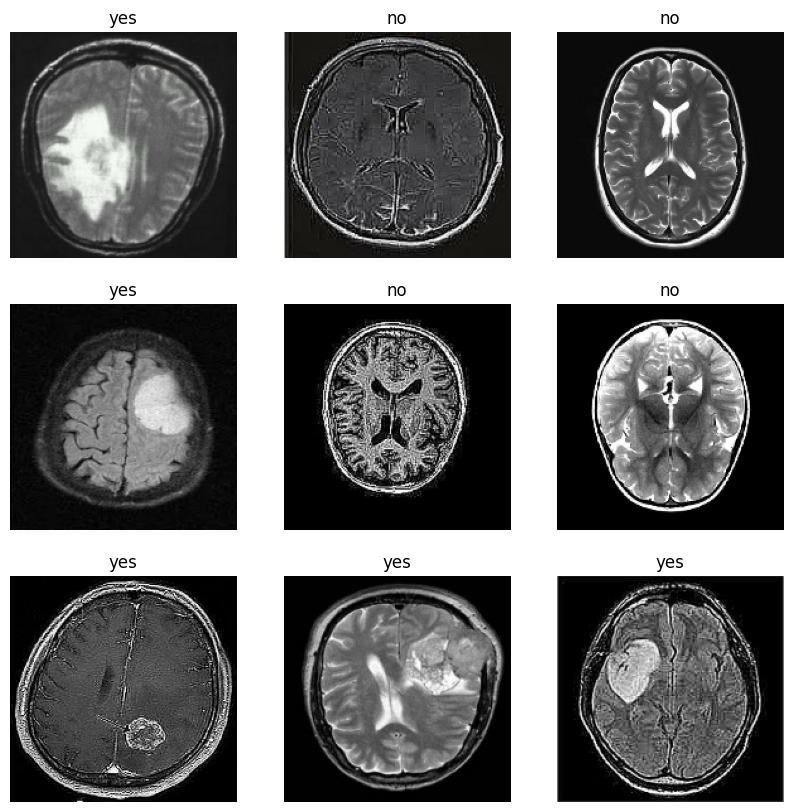

In [ ]:
#visualize data
#first 10 images of training data set
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [ ]:
#configure data to for model performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

#normalize RGB values of layers
normalization_layer = layers.Rescaling(1./255)

In [ ]:
#create Keras Model
num_classes = len(class_names)

model = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

In [ ]:
#compile the model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
#model summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 180, 180, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2  (None, 90, 90, 16)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 90, 90, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 45, 45, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 45, 45, 64)        1

In [ ]:
#train the model
epochs=10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/10
75/75 [==============================] - 105s 1s/step - loss: 0.5411 - accuracy: 0.7663 - val_loss: 0.3451 - val_accuracy: 0.8300
Epoch 2/10
75/75 [==============================] - 86s 1s/step - loss: 0.2779 - accuracy: 0.8833 - val_loss: 0.1630 - val_accuracy: 0.9483
Epoch 3/10
75/75 [==============================] - 84s 1s/step - loss: 0.1181 - accuracy: 0.9617 - val_loss: 0.1042 - val_accuracy: 0.9733
Epoch 4/10
75/75 [==============================] - 92s 1s/step - loss: 0.0535 - accuracy: 0.9871 - val_loss: 0.0829 - val_accuracy: 0.9800
Epoch 5/10
75/75 [==============================] - 87s 1s/step - loss: 0.0267 - accuracy: 0.9950 - val_loss: 0.0816 - val_accuracy: 0.9850
Epoch 6/10
75/75 [==============================] - 85s 1s/step - loss: 0.0238 - accuracy: 0.9950 - val_loss: 0.0774 - val_accuracy: 0.9867
Epoch 7/10
75/75 [==============================] - 88s 1s/step - loss: 0.0040 - accuracy: 0.9996 - val_loss: 0.0975 - val_accuracy: 0.9850
Epoch 8/10
75/75 [=

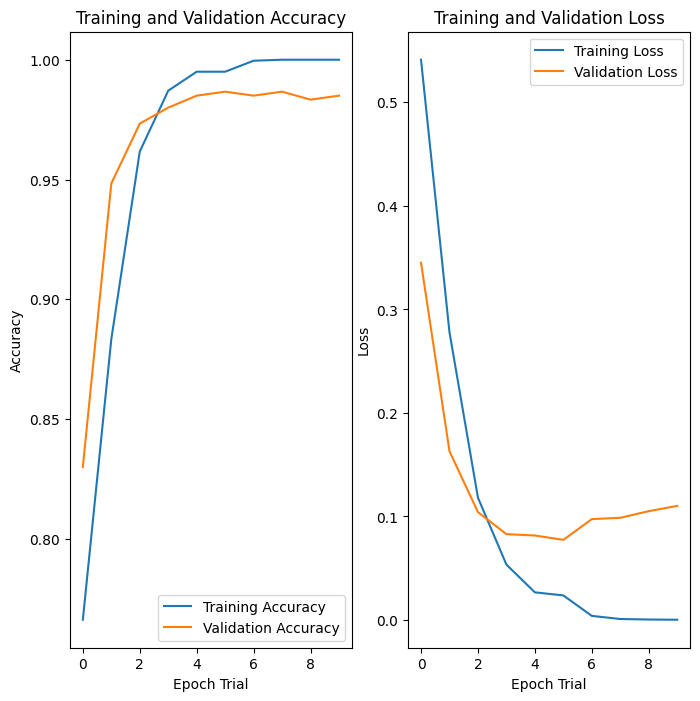

In [ ]:
#visualize training metrics
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.xlabel('Epoch Trial')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.xlabel('Epoch Trial')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
#Classify new image (not in dataset) and no tumor or yes tumor

#get prediction set from google drive
# Path to the zip file in your Google Drive
prediction_path = '/content/drive/My Drive/Spring2024/CS365/prediction_set.zip'

# Destination path where you want to save the zip file
save_prediction_path = '/content/brain_tumor_set.zip'

# Copy the file from Google Drive to Colab's local filesystem
shutil.copy(prediction_path, save_prediction_path)

print("File downloaded successfully!")

#extract folders from zip file

# Directory where you want to extract the images
extracted_images_dir = '/content/brain_tumor_set'

# Extract the zip file
with zipfile.ZipFile(save_prediction_path) as zip_ref:
    zip_ref.extractall(extracted_images_dir)

#path to predictions file
pred_path = os.path.join(extracted_images_dir, 'pred')

# List the extracted image files
image_files = os.listdir(pred_path)
print("Extracted image files:", image_files)
print(len(image_files))


pred_file_path = os.path.join(pred_path, image_files[8]) #index is which image you are going to use for prediction
print(pred_file_path)


File downloaded successfully!
Extracted image files: ['pred28.jpg', 'pred59.jpg', 'pred9.jpg', 'pred43.jpg', 'pred39.jpg', 'pred7.jpg', 'pred40.jpg', 'pred53.jpg', 'pred2.jpg', 'pred23.jpg', 'pred56.jpg', 'pred3.jpg', 'pred41.jpg', 'pred37.jpg', 'pred54.jpg', 'pred52.jpg', 'pred15.jpg', 'pred42.jpg', 'pred14.jpg', 'pred19.jpg', 'pred31.jpg', 'pred27.jpg', 'pred46.jpg', 'pred26.jpg', 'pred34.jpg', 'pred30.jpg', 'pred5.jpg', 'pred38.jpg', 'pred10.jpg', 'pred12.jpg', 'pred29.jpg', 'pred55.jpg', 'pred35.jpg', 'pred24.jpg', 'pred45.jpg', 'pred0.jpg', 'pred16.jpg', 'pred33.jpg', 'pred1.jpg', 'pred49.jpg', 'pred4.jpg', 'pred17.jpg', 'pred58.jpg', 'pred11.jpg', 'pred18.jpg', 'pred47.jpg', 'pred22.jpg', 'pred20.jpg', 'pred21.jpg', 'pred48.jpg', 'pred50.jpg', 'pred32.jpg', 'pred51.jpg', 'pred44.jpg', 'pred36.jpg', 'pred6.jpg', 'pred13.jpg', 'pred8.jpg', 'pred57.jpg', 'pred25.jpg']
60
/content/brain_tumor_set/pred/pred2.jpg


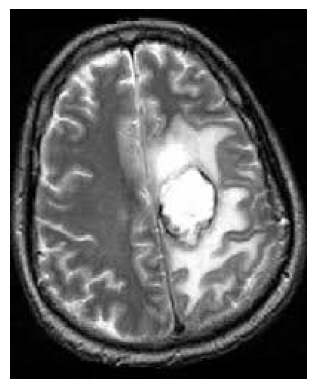

1/1 [==============================] - 0s 34ms/step
yes this image contains a tumor with a 99.96 percent confidence.


In [ ]:
img = mpimg.imread(pred_file_path)

# Display the image
plt.imshow(img)
plt.axis('off')  # Turn off axis
plt.show()

#predict if there is a tumor
img = tf.keras.utils.load_img(
    pred_file_path, target_size=(img_height, img_width)
)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "{} this image contains a tumor with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)
